# Comprension de datos

## Set CD to root

In [1]:
import os
from pathlib import Path
print("Directorio actual:", os.getcwd())

current_dir = Path.cwd()
project_root = current_dir
while not (project_root / '.git').exists() and project_root != project_root.parent:
    project_root = project_root.parent
    os.chdir("..")

print(f"Raíz del proyecto: {project_root}")
print("CWD cambiado a raíz del proyecto")


Directorio actual: c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B\notebooks
Raíz del proyecto: c:\Users\santi\OneDrive\Documents\GitHub\PROYECTO_MA2003B
CWD cambiado a raíz del proyecto


## Lectura de datos

In [2]:
import pandas as pd

path_master_table = 'data/processed/master_table.csv'
df_master_table = pd.read_csv(path_master_table)

In [3]:
# Dimensiones del dataset
print("Dimensiones del dataset:")
print(f"Registros: {df_master_table.shape[0]}")
print(f"Columnas: {df_master_table.shape[1]}\n")


Dimensiones del dataset:
Registros: 386494
Columnas: 18



In [4]:
# Descripción de variables
print("Información de las variables:")
print(df_master_table.info())

Información de las variables:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386494 entries, 0 to 386493
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date_index      386494 non-null  object 
 1   co              364616 non-null  float64
 2   no              368735 non-null  float64
 3   no2             371092 non-null  float64
 4   nox             371546 non-null  float64
 5   o3              369094 non-null  float64
 6   pm10            373557 non-null  float64
 7   pm2.5           290296 non-null  float64
 8   prs             376939 non-null  float64
 9   rainf           380321 non-null  float64
 10  rh              353052 non-null  float64
 11  so2             359556 non-null  float64
 12  sr              369380 non-null  float64
 13  tout            370843 non-null  float64
 14  wsr             376200 non-null  float64
 15  wdr             375142 non-null  float64
 16  estacion        386494 non

In [5]:
# Resumen estadístico
print("Resumen estadístico:")
print(df_master_table.describe())

Resumen estadístico:
                  co             no            no2            nox  \
count  364616.000000  368735.000000  371092.000000  371546.000000   
mean        1.363758      11.971078      15.325864      27.112617   
std         0.822914      20.414565      11.299054      27.775757   
min        -0.130000       0.300000       0.000000       0.500000   
25%         0.740000       3.200000       7.300000      11.500000   
50%         1.230000       5.200000      12.200000      18.300000   
75%         1.820000      11.600000      20.300000      31.500000   
max        37.000000     945.100000     167.800000     971.800000   

                  o3           pm10          pm2.5            prs  \
count  369094.000000  373557.000000  290296.000000  376939.000000   
mean       26.928444      60.956876      20.535832     715.292530   
std        18.619548      42.781271      16.412458       9.317445   
min        -9.000000       1.000000      -1.000000     655.400000   
25%        1

In [6]:
# Valores nulos
print("Valores nulos por columna:")
print(df_master_table.isnull().sum())

Valores nulos por columna:
date_index            0
co                21878
no                17759
no2               15402
nox               14948
o3                17400
pm10              12937
pm2.5             96198
prs                9555
rainf              6173
rh                33442
so2               26938
sr                17114
tout              15651
wsr               10294
wdr               11352
estacion              0
archivo_origen        0
dtype: int64


=== ANÁLISIS DE VARIABLES CUANTITATIVAS ===

Estadísticas para co:
Media: 1.36
Mediana: 1.23
Moda: 0.70
Rango: 37.13
Desviación Estándar: 0.82
Varianza: 0.68

Estadísticas para no:
Media: 11.97
Mediana: 5.20
Moda: 2.60
Rango: 944.80
Desviación Estándar: 20.41
Varianza: 416.75

Estadísticas para no2:
Media: 15.33
Mediana: 12.20
Moda: 6.70
Rango: 167.80
Desviación Estándar: 11.30
Varianza: 127.67

Estadísticas para nox:
Media: 27.11
Mediana: 18.30
Moda: 9.80
Rango: 971.30
Desviación Estándar: 27.78
Varianza: 771.49

Estadísticas para o3:
Media: 26.93
Mediana: 23.00
Moda: 16.00
Rango: 192.00
Desviación Estándar: 18.62
Varianza: 346.69

Estadísticas para pm10:
Media: 60.96
Mediana: 52.00
Moda: 43.00
Rango: 1000.00
Desviación Estándar: 42.78
Varianza: 1830.24

Estadísticas para pm2.5:
Media: 20.54
Mediana: 17.00
Moda: 10.00
Rango: 1000.00
Desviación Estándar: 16.41
Varianza: 269.37

Estadísticas para prs:
Media: 715.29
Mediana: 714.50
Moda: 729.00
Rango: 92.20
Desviación Estándar: 9.32
Vari

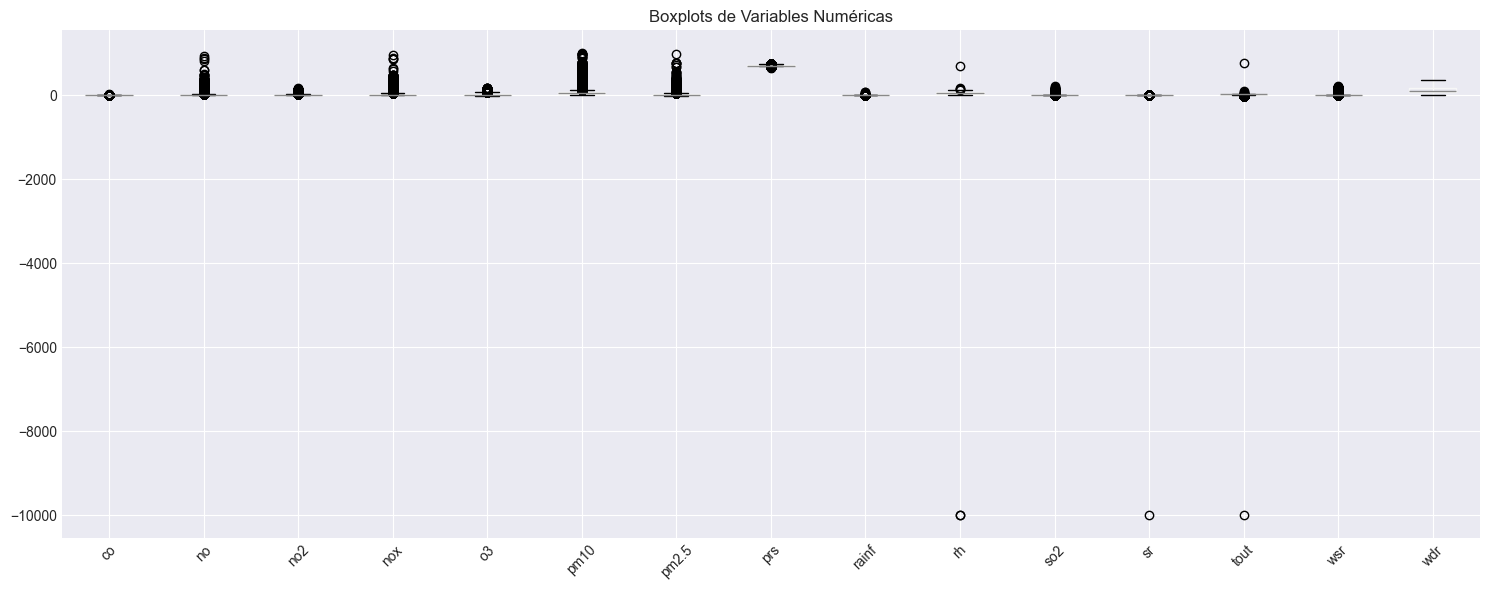

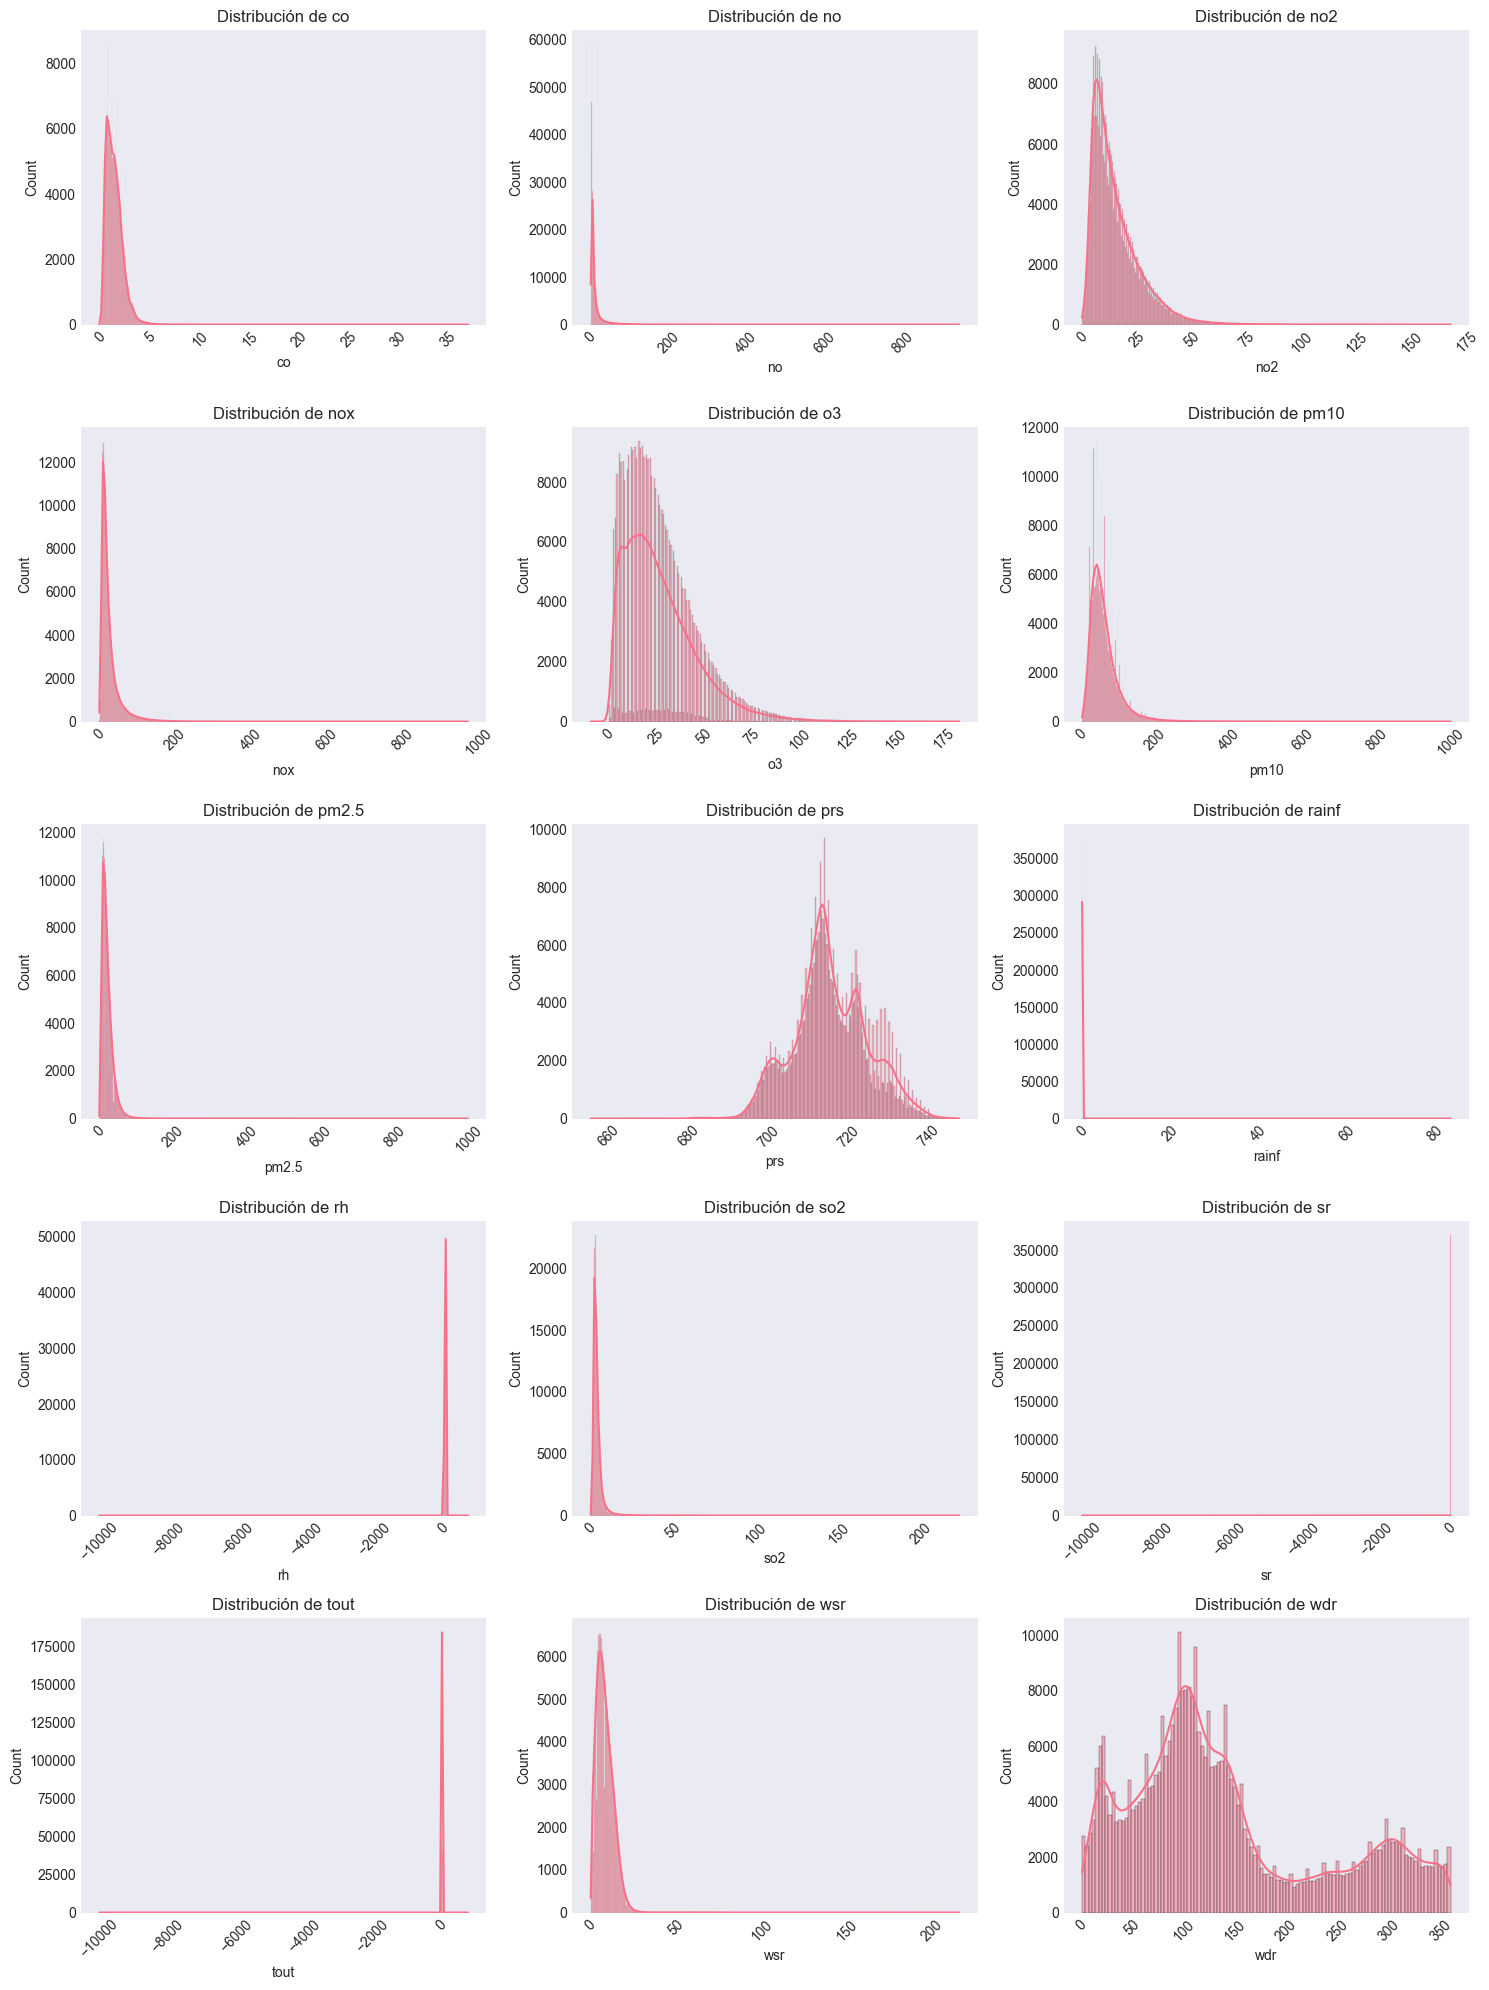

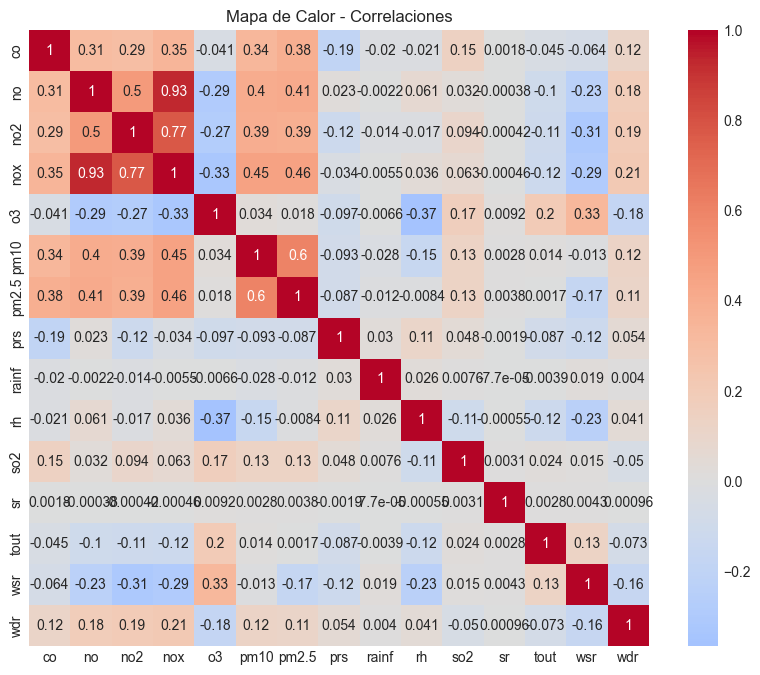

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Configuración de estilo para las visualizaciones
plt.style.use('seaborn-v0_8-dark')
sns.set_palette("husl")

# Separar variables numéricas y categóricas
numerical_cols = df_master_table.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_master_table.select_dtypes(include=['object', 'category']).columns

# 1. Análisis de variables cuantitativas
print("=== ANÁLISIS DE VARIABLES CUANTITATIVAS ===")
for col in numerical_cols:
    print(f"\nEstadísticas para {col}:")
    stats = {
        'Media': df_master_table[col].mean(),
        'Mediana': df_master_table[col].median(),
        'Moda': df_master_table[col].mode().iloc[0],
        'Rango': df_master_table[col].max() - df_master_table[col].min(),
        'Desviación Estándar': df_master_table[col].std(),
        'Varianza': df_master_table[col].var()
    }
    for stat, value in stats.items():
        print(f"{stat}: {value:.2f}")

# Visualizaciones para boxplots
plt.figure(figsize=(15, 6))
df_master_table[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplots de Variables Numéricas')
plt.tight_layout()
plt.show()

# Visualizaciones para histogramas
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
fig = plt.figure(figsize=(15, 4*n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=df_master_table, x=col, kde=True)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(df_master_table[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Mapa de Calor - Correlaciones')
plt.show()